# Инициализация БД

In [1]:
import duckdb
import plotly.express as px

In [2]:
duckdb.query(
    """
    CREATE OR REPLACE TABLE ship_types (
        ship_id INTEGER PRIMARY KEY,
        ship_name VARCHAR(50) NOT NULL,
        min_delay_days INTEGER NOT NULL,
        max_delay_days INTEGER NOT NULL
    );
    
    INSERT INTO ship_types VALUES
        (1, 'Самовывоз', 0, 30),
        (2, 'Курьер пеший', 0, 30),
        (3, 'Курьер СИМ', 0, 30),
        (4, 'Курьер авто', 0, 30),
        (5, 'Доставка межгород авто', 1, 15),
        (6, 'Доставка межгород авиа', 2, 10),
        (7, 'Доставка межгород вода', 30, 120);
    """
)

In [3]:
duckdb.query(
    """
    CREATE OR REPLACE TABLE orders AS
    FROM 'orders.parquet'
    """
)

# Исследование данных

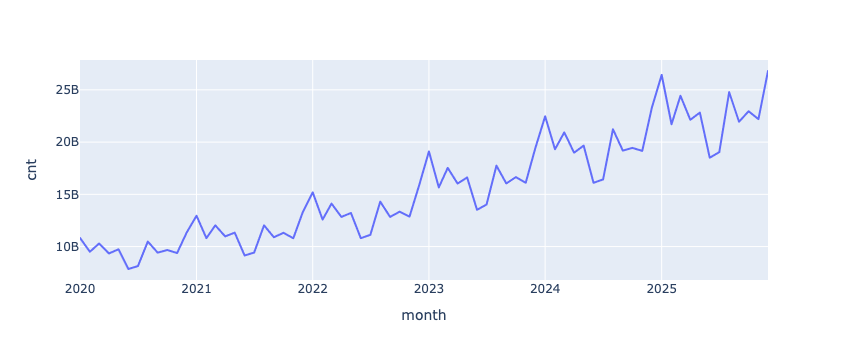

In [4]:
df = duckdb.query(
    """
    SELECT
        date_trunc('month', order_date) AS month,
        sum(amount) AS cnt
    FROM
        orders
    WHERE
        1=1
    GROUP BY 1 
    ORDER BY 1
    """
).df()

fig = px.scatter(
    df, 
    x='month', 
    y='cnt', 
    render_mode='webgl'
)
fig.update_traces(mode='lines')

fig.show()

# Что такое партиция на физическом примере

Представьте офис с большим архивом документов. Все договоры, счета и акты за 10 лет лежат в одной огромной комнате в случайном порядке.

Когда бухгалтер приходит и говорит "*найди мне все счета за март 2023*" — помощник идёт в комнату и перебирает каждый документ. Это `Seq Scan` по всей таблице.

Теперь представьте, что в той же комнате поставили стеллажи с ящиками, подписанными по месяцам:

```bash
[2022 Янв] [2022 Фев] [2022 Мар] ...
[2023 Янв] [2023 Фев] [2023 Мар] ...
```

Бухгалтер говорит "*найди мне все счета за март 2023*" — помощник сразу идёт к нужному ящику, открывает только его и достаёт документы. Остальные ящики даже не трогает. Это `partition pruning`.

![](images/partition_example_archive.png)

# Как выбрать ключ для партиционирования

Давайте представим ситуацию как будто нам необходимо самим выбрать как сделать стеллажи с ящиками?

Как выбрать корректный ключ для партиционирования?

---

**Идея \#1: "*А давайте сделаем ящик под каждый конкретный день за все 10 лет*"**

|Что происходит в архиве|Что происходит в базе данных|
|---|---|
|В комнате появляется лабиринт из 3'650 крошечных ящиков. Чтобы найти документы за весну 2023 года, помощнику приходится выдвигать, заглядывать и задвигать 90 отдельных ящиков.|Это избыточное количество партиций. СУБД тратит кучу ресурсов (памяти и CPU) только на то, чтобы менеджер запросов просмотрел метаданные тысяч партиций и решил, какие из них нужны|

![](images/3650_parts.png)

**Идея \#2: "*Сделаем по ящику на каждого контрагента*"**

|Что происходит в архиве|Что происходит в базе данных|
|---|---|
|У вас есть один гигантский клиент (например, Google) и 500 мелких ИП. В итоге ящик "Google" — это огромный шкаф, который ломится от бумаг и падает, а в остальных 500 ящиках лежит по одному листочку.|Это классический перекос данных (`data skew`). Одна партиция весит терабайт, остальные по мегабайту. Теряется весь смысл деления: запросы к крупному клиенту по-прежнему будут тормозить, а диск будет нагружаться неравномерно.

![](images/one_big_part.png)

**Идея \#3: "*Поставим всего два огромных ящика: в один складываем Акты, в другой — Счета*"**

|Что происходит в архиве|Что происходит в базе данных|
|---|---|
|Приходит бухгалтер и говорит: "*Найди мне счёт по компании Х за май 2024*". Помощник радостно подходит к ящику "Счета"... а там лежит ровно половина всего 10-летнего архива компании (миллион документов). Ему всё равно приходится перебирать гору бумаги вручную.|Слишком низкая селективность ключа. Если у вас всего 2-3 партиции, база данных отсечёт половину данных, но оставшаяся половина всё равно будет слишком огромной для быстрого поиска. Эффект от `partition pruning` минимален.

![](images/two_big_parts.png)

## Так какой ключ для партиций выбрать?

Правильный ключ партиционирования — **это баланс**.

- Если сделать ящики слишком большими (по типу документа) — помощник устанет искать внутри ящика.
- Если сделать их по непредсказуемому признаку (по клиентам) — один ящик переполнится, а другие будут пустовать.
- Если сделать их слишком мелкими (по дням) — помощник устанет бегать между тысячами ящиков.

> **Но есть Но:<br>**
> "*Неправильный*" ключ для партиционирования для вас может оказаться "*правильным*".

## Почему "*неправильное*" становится "*правильным*"?

Потому что ключ партиционирования выбирается, когда вы понимаете какое условие чаще всего используется в конструкции `WHERE`.

Давайте рассмотрим на примере.

In [5]:
duckdb.query("FROM orders LIMIT 1").df()

,order_id,customer_id,employee_id,ship_city_id,ship_id,order_date,shipped_date,receipt_date,amount
0,663a8db8-801c-4ead-b687-40ca4cf392b6,33efb014-a1a9-44a3-9fb8-ca497ec913b7,9411ab34-1b0f-4324-9dcb-8c32103240db,64ffca64-c16d-43ce-b683-89674c36e71f,5,2020-06-08 12:09:08,2020-06-19 03:29:05,2020-06-22 12:26:23,16884.62


## Анализ дат

У нас есть три разных даты:
- `order_date` — дата оформления заказа. Это именно когда мы оформили наш заказ. К примеру, когда мы готовимся к празднику, то заранее заказываем его.
- `shipped_date` — дата доставки заказа. Ну тут всё исходит из названия колонки. Это дата, когда наш заказанный товар пришел на ПВЗ.
- `receipt_date` — дата получения заказа. Здесь я тоже думаю, что всё очевидно и это дата, когда именно мы получили наш заказ из ПВЗ.

Стоить иметь ввиду, что у нас даты почти всегда смещены и для анализа — это важный элемент, который мы рассмотрим в течение ролика.

### Сдвиг дат по `order_date`, `shipped_date` и `receipt_date`

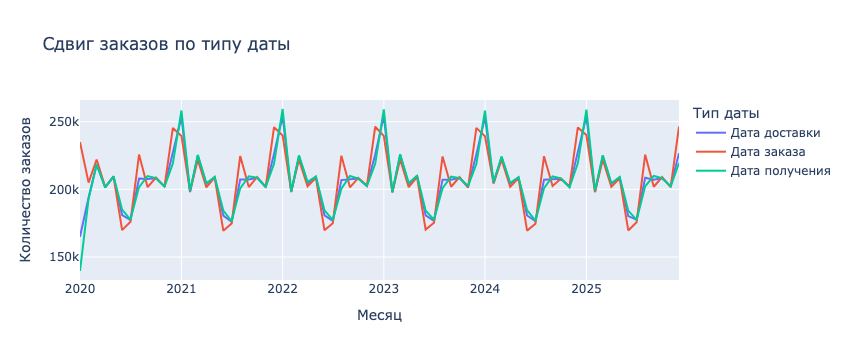

In [6]:
df = duckdb.query(
    """
    SELECT date_trunc('month', order_date) AS month, 'Дата заказа' AS date_type, count(*) AS cnt
    FROM orders
    GROUP BY 1

    UNION ALL

    SELECT date_trunc('month', shipped_date) AS month, 'Дата доставки' AS date_type, count(*) AS cnt
    FROM orders
    WHERE 1=1
        AND shipped_date < '2026-01-01'
    GROUP BY 1

    UNION ALL

    SELECT date_trunc('month', receipt_date) AS month, 'Дата получения' AS date_type, count(*) AS cnt
    FROM orders
    WHERE 1=1
        AND receipt_date < '2026-01-01'
    GROUP BY 1

    ORDER BY 1, 2
    """
).df()

fig = px.line(
    df,
    x='month',
    y='cnt',
    color='date_type',
    labels={
        'month': 'Месяц',
        'cnt': 'Количество заказов',
        'date_type': 'Тип даты'
    },
    title='Сдвиг заказов по типу даты'
)
fig.show()

### Средний срок доставки заказа

In [7]:
duckdb.query("FROM ship_types").df()

,ship_id,ship_name,min_delay_days,max_delay_days
0,1,Самовывоз,0,30
1,2,Курьер пеший,0,30
2,3,Курьер СИМ,0,30
3,4,Курьер авто,0,30
4,5,Доставка межгород авто,1,15
5,6,Доставка межгород авиа,2,10
6,7,Доставка межгород вода,30,120


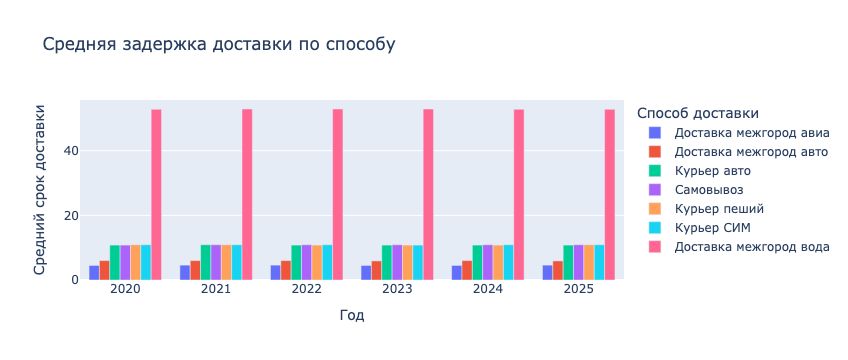

In [8]:
df = duckdb.query(
    """
    SELECT
        date_trunc('year', order_date) AS year,
        ship_name,
        ROUND(AVG(EPOCH(shipped_date - order_date)) / 86400, 1) AS avg_delay_days
    FROM
        orders AS o
        JOIN ship_types AS st USING (ship_id)
    WHERE
        1=1
    GROUP BY
        1, 2
    ORDER BY
        1, 3
    """
).df()

fig = px.bar(
    df,
    x='year',
    y='avg_delay_days',
    color='ship_name',
    barmode='group',  # grouped — столбцы рядом, не стопкой
    labels={
        'year': 'Год',
        'avg_delay_days': 'Средний срок доставки',
        'ship_name': 'Способ доставки'
    },
    title='Средняя задержка доставки по способу'
)
fig.show()

### Сдвиг дат по `shipped_date` и `receipt_date`

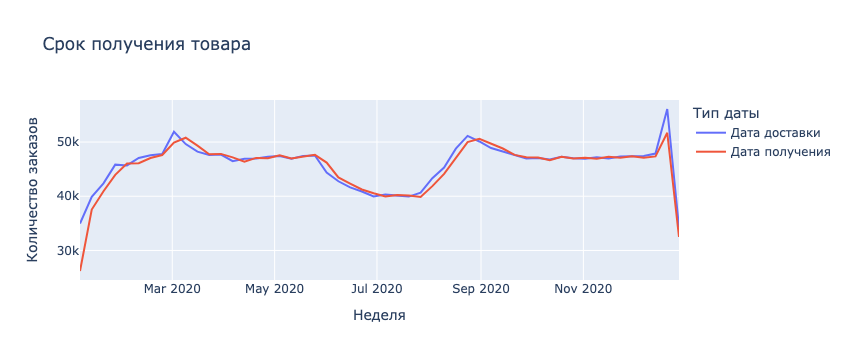

In [9]:
df = duckdb.query(
    """
    SELECT week, date_type, cnt
    FROM (
        SELECT date_trunc('week', shipped_date) AS week, 'Дата доставки' AS date_type, count(*) AS cnt
        FROM orders
        WHERE shipped_date >= '2020-01-01' AND shipped_date < '2021-01-01'
        GROUP BY 1

        UNION ALL

        SELECT date_trunc('week', receipt_date) AS week, 'Дата получения' AS date_type, count(*) AS cnt
        FROM orders
        WHERE receipt_date >= '2020-01-01' AND receipt_date < '2021-01-01'
        GROUP BY 1
    )
    WHERE week >= '2020-01-01' AND week < '2021-01-01'
    ORDER BY 1, 2
    """
).df()

fig = px.line(
    df,
    x='week',
    y='cnt',
    color='date_type',
    labels={
        'week': 'Неделя',
        'cnt': 'Количество заказов',
        'date_type': 'Тип даты'
    },
    title='Срок получения товара'
)
fig.show()

## Анализ списков

- `order_id` — уникальный `id` заказа.
- `customer_id` — уникальный `id` пользователя.
- `employee_id` — уникальный `id` сотрудника.
- `ship_city_id` — уникальный `id` города.
- `ship_id` — уникальный `id` способа доставки.

### Количество, сумма и средняя сумма заказов по клиентам

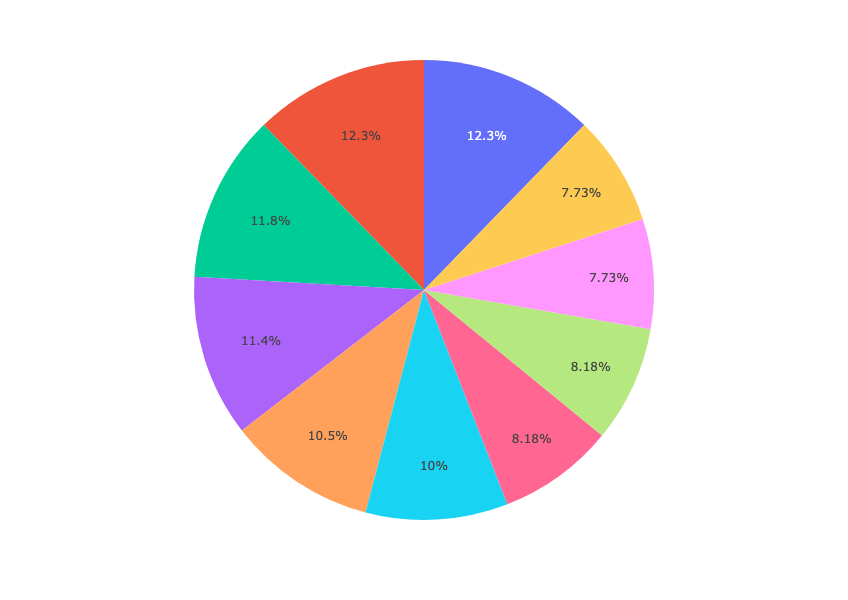

In [10]:
df = duckdb.query(
    """
    SELECT
        customer_id,
        COUNT(*) AS cnt_orders,
        ROUND(SUM(amount), 2) AS total_amount,
        ROUND(AVG(amount), 2) AS avg_amount
    FROM
        orders
    GROUP BY customer_id
    ORDER BY total_amount DESC
    LIMIT 10
    """
).df()

fig = px.pie(data_frame=df, values='cnt_orders', names='customer_id', height=600)
fig.update_layout(showlegend=False)
fig.show()

## Резюме

И вот только после анализа данных, запросов аналитиков и прочих моментов мы должны выбрать ключ партиционирования, который подойдет больше всего для нас.

Если говорить верхнеуровнево про партиционирование, то выделяется два типа:
- Интервальное — даты. В нашем случае это может быть `order_date`, `shipped_date` или `receipt_date`.
- Перечисление — списки. В нашем случае это может быть `order_id`, `customer_id`, `employee_id`, `ship_city_id` и `ship_id`.

И в зависимости от задачи вы уже выбираете свой ключ. И поэтому, повторюсь, "*неправильное*" может стать "*правильным*".

Если формализовать правила, то:
- **Хороший ключ:**
    - Умеренная селективность.
    - Часто в `WHERE`.
- **Плохой ключ:**
    - Высокая селективность, к примеру, `uuid`.
    - Маленькие значения, к примеру, `timestamp` до секунды.
    - Не используется в конструкции `WHERE`
    - Не является бизнес-ключом для архивирования или TTL